# 📊 月次売上と累積売上

今期・前期の月次売上を並列棒グラフで比較し、今期の累積売上を折れ線で表示する。

> ※ 本notebookはローカルモジュール（`Lv01_03_configuration`）に依存しているため、単体での実行はできません。分析の流れとアウトプットの確認を目的としています。

In [6]:
# ================================================ #
# imports
# ================================================ #

# 標準ライブラリ
import sys
from pathlib import Path

# 外部ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.ticker import FuncFormatter
from IPython.display import display

# ローカルモジュール
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path.cwd().parents[1]))
sys.path.insert(0, str(Path.cwd().parents[2]))
from Lv01_03_configuration.cnfg_b_dir_01_local import DIRS
from Lv01_03_configuration.cnfg_d_proc_01_merged import(
    Proc01info, Cols
)
from Lv01_03_configuration.cnfg_u_local_02_function import(
    generate_dic_ym_to_fiscal_quarter
)

from Lv01_03_configuration.cnfg_p_chart import (
    generate_chart_monthly_sales_with_cumulative
)

from Lv01_03_configuration.cnfg_a_api_01_pub import (
    pmod_01_loading_df as func_loading_df,
    pmod_20_formatting_datetime as func_datetime_format,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# ================================================ #
# データ読み込み・加工
# ================================================ #
# データ読み込み
df = func_loading_df.read_as_dataframe_from_excel_or_csv(
    target_file_path= Path(DIRS.Processed) / Proc01info.FILENAME
)

# 年月カラムの追加
df = (
    df.copy()
    .pipe(
        func_datetime_format.format_ss_half_y4m2,
        target_col          = Cols.order_date,
        output_col          = Cols.order_ym,
        trans_to_datetime   = True
    )
)

# 集計期間の設定
fiscal_start_month  = 1
start_year          = 2025
start_month         = 1
end_year            = start_year
end_month           = 12

# 今期・前期の年月リスト生成
dic_current_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month  = fiscal_start_month,
    start_year          = start_year,
    start_month         = start_month,
    end_year            = end_year,
    end_month           = end_month
)

dic_previous_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month  = fiscal_start_month,
    start_year          = start_year - 1,
    start_month         = start_month,
    end_year            = end_year - 1,
    end_month           = end_month
)

current_list_full   = list(dic_current_quarter)
current_list        = current_list_full[:7]
previous_list = list(dic_previous_quarter)

# 今期・前期のデータ抽出
current_df = (
    df.loc[df[Cols.order_ym].isin(current_list)]
    .copy()
    .reset_index(drop=True)
)

previous_df = (
    df.loc[df[Cols.order_ym].isin(previous_list)]
    .copy()
    .reset_index(drop=True)
)


# 集計関数
def agg_for_summary(
    target_df,
    group_col
):
    df_sample = (
    target_df
    .groupby(group_col, as_index=False).agg(
        **{
            Cols.sales_sum      : (Cols.sales, "sum"),
            Cols.sales_profit   : (Cols.profit, "sum"),
            Cols.buyer_count    : (Cols.customer_name, "count"),
            Cols.sales_count    : (Cols.quantity , "sum")
        }
    )
    )

    df_sample[Cols.sales_sum] = df_sample[Cols.sales_sum].round(1)
    df_sample[Cols.sales_profit] = df_sample[Cols.sales_profit].round(1)

    return df_sample


# 集計
x_axis_col  = Cols.order_ym
group_cols  = [x_axis_col]
current_df  = agg_for_summary(current_df, group_cols)
previous_df = agg_for_summary(previous_df, group_cols)

# 全月分の枠を作成してマージ
current_full = pd.MultiIndex.from_product(
    [current_list_full], names=[x_axis_col]
).to_frame(index=False)

current_df = current_full.merge(
    right= current_df[[Cols.order_ym, "sales_sum"]],
    on= Cols.order_ym,
    how= 'left',
).fillna(0)

# 前期データをマージ
dic_current_to_previous = dict(zip(current_list_full, previous_list))
current_df["order_ym_previous"] = current_df[Cols.order_ym].map(dic_current_to_previous)
current_df = current_df.merge(
    right= previous_df[[Cols.order_ym, "sales_sum"]],
    left_on= "order_ym_previous",
    right_on= Cols.order_ym,
    how= 'left',
    suffixes=("", "_prev")
)

# 累積売上の計算
mask = current_df["sales_sum"] != 0
current_df.loc[mask, "sales_cumulative"] = current_df["sales_sum"].cumsum()
current_df = current_df.reindex(
    columns=["order_ym", "sales_sum", "sales_sum_prev", "sales_cumulative"]
)


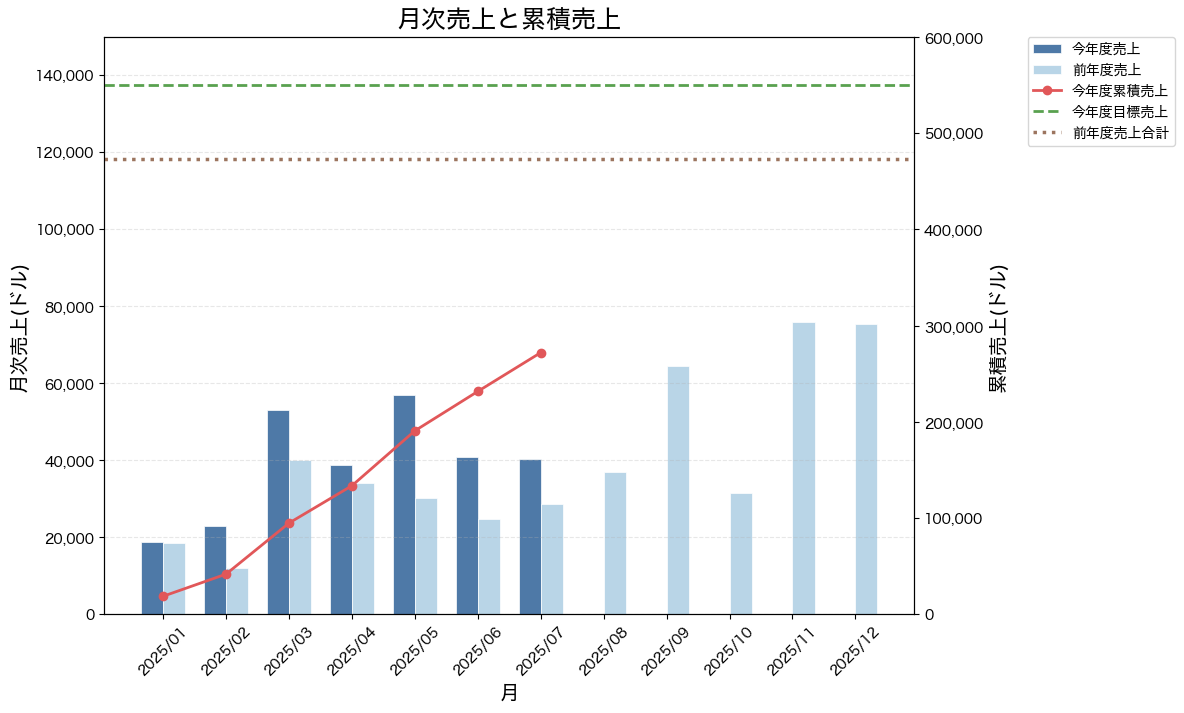

In [8]:
# チャート描画
plt.rcParams['font.family'] = 'Hiragino Sans'
fig, ax = plt.subplots(figsize=(12, 7.5))

generate_chart_monthly_sales_with_cumulative(
    df_target             = current_df,
    ax                    = ax,
    col_month             = "order_ym",
    col_sales_current     = "sales_sum",
    col_sales_previous    = "sales_sum_prev",
    col_cumulative        = "sales_cumulative",
    label_sales_current   = "今年度売上",
    label_sales_previous  = "前年度売上",
    label_cumulative      = "今年度累積売上",
    label_target          = "今年度目標売上",
    label_previous_total  = "前年度売上合計",
    target_value          = 550000,
    rotation              = 45,
    legend_loc            = "upper left",
    legend_bbox_to_anchor = (1.14, 1.0),
    ylim_left             = (0, 150000),
    ylim_right            = (0, 600000),
)

plt.subplots_adjust(right=0.80)
plt.show()